# 06 · Evaluation: Does Anything Beat the Baseline?

Runs entirely on the cached out-of-fold predictions from stage 04 — no model is re-fitted
here, which is what makes the bootstrap work affordable.

The stage opens with the question the study exists to answer and had never actually
tested: **for each target, does any model beat a naive baseline by more than noise?** The
results table alone cannot answer that, because "which RMSE is smaller" and "is this model
better" are different questions at 30 test points. Two independent tests are applied — a
paired event-level bootstrap and a Diebold–Mariano test on the loss differential — and a
model is only credited with beating a baseline when both agree.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "_shared.py").exists() else Path.cwd() / "notebooks"))
from _shared import *  # noqa: F401,F403

from src.evaluation import figures as fx
fx.apply_thesis_style()

import numpy as np

dataset = load_frame("dataset")
spec = load_json("feature_spec")
FEATURE_COLS, TARGET_COLS = spec["FEATURE_COLS"], spec["TARGET_COLS"]
X = dataset[FEATURE_COLS].fillna(0.0)
y = dataset[TARGET_COLS].copy()
results = load_object("results_regression")
splits = load_object("splits")
train_fit_r2 = load_json("train_fit_r2")
print(f"\nloaded {len(results)} model result sets: {sorted(results)}")



loaded 8 model result sets: ['ensemble', 'mlp', 'naive_train_mean', 'naive_zero', 'random_forest', 'ridge', 'stacked', 'xgboost']


## Stage 0 — the predictability verdict

The decision rule is fixed in advance: a model **beats** a baseline only if the paired
bootstrap 95% interval on ΔRMSE excludes zero **and** the Diebold–Mariano test agrees at
the 5% level. A point estimate that merely happens to be positive is not evidence at this
sample size.

Both nulls must be cleared: `naive_zero` ("the disaster had no measurable effect") and
`naive_train_mean` (the best constant a model could have learned from its training fold).

In [2]:
from src.evaluation.verification import verdict_table

verdict = verdict_table(results, TARGET_COLS)
save_frame(verdict, "verdict_table", "Stage-0 predictability verdicts, bootstrap + Diebold-Mariano.")

pd.set_option("display.width", 200)
print(verdict[["target", "model", "baseline", "n", "rmse_model", "rmse_baseline",
               "delta_rmse", "ci_low", "ci_high", "dm_p", "verdict"]].to_string(index=False))


cached verdict_table.parquet  (36 rows x 15 cols)
            target         model         baseline  n  rmse_model  rmse_baseline  delta_rmse     ci_low   ci_high     dm_p                     verdict
Y1_aspi_log_return         ridge       naive_zero 40    0.014822       0.014340   -0.000482  -0.002137  0.000674 0.460083         worse than baseline
Y1_aspi_log_return         ridge naive_train_mean 40    0.014822       0.014707   -0.000115  -0.001253  0.001577 0.856503         worse than baseline
Y1_aspi_log_return random_forest       naive_zero 40    0.014107       0.014340    0.000233  -0.001144  0.001198 0.723889 better, not distinguishable
Y1_aspi_log_return random_forest naive_train_mean 40    0.014107       0.014707    0.000600  -0.000133  0.001678 0.111636 better, not distinguishable
Y1_aspi_log_return       xgboost       naive_zero 40    0.016894       0.014340   -0.002554  -0.006479  0.000385 0.194827         worse than baseline
Y1_aspi_log_return       xgboost naive_train_mean 

In [3]:
print("PER-TARGET VERDICT\n" + "=" * 70)
for t in TARGET_COLS:
    sub = verdict[verdict["target"] == t]
    winners = sorted(set(sub.loc[sub["verdict"] == "BEATS BASELINE", "model"]))
    # A model only counts if it clears BOTH nulls.
    both = [m for m in winners
            if (sub[(sub["model"] == m) & (sub["verdict"] == "BEATS BASELINE")]["baseline"].nunique() == 2)]
    if both:
        print(f"{t}: PREDICTABLE -- {', '.join(both)} beat both nulls with CIs excluding zero.")
    elif winners:
        print(f"{t}: partial -- {', '.join(winners)} beat one null but not both.")
    else:
        best = sub.loc[sub["delta_rmse"].idxmax()]
        print(f"{t}: NOT DISTINGUISHABLE from its baselines. Best is {best['model']} "
              f"(delta RMSE {best['delta_rmse']:+.4g}, 95% CI [{best['ci_low']:+.4g}, "
              f"{best['ci_high']:+.4g}] -- straddles zero).")


PER-TARGET VERDICT
Y1_aspi_log_return: NOT DISTINGUISHABLE from its baselines. Best is mlp (delta RMSE +0.0009313, 95% CI [-0.0004433, +0.00293] -- straddles zero).
Y2_abnormal_volume: NOT DISTINGUISHABLE from its baselines. Best is ensemble (delta RMSE +0.0713, 95% CI [-0.01456, +0.1524] -- straddles zero).
Y3_recovery_days: NOT DISTINGUISHABLE from its baselines. Best is random_forest (delta RMSE +0.2265, 95% CI [-0.2231, +0.629] -- straddles zero).


## 10. Evaluation Summary — H1 Test, Per Target

Thesis H1 (§3.1.2): *Random Forest / MLP can effectively forecast the targets, i.e. beat the linear (Ridge) baseline.* Tested here directly for **all three targets separately** (Y1 ASPI return, Y2 abnormal volume, Y3 recovery days) — not just Y1, which is all the original pass of this notebook scored. If a model's RMSE is below Ridge's on a given target, H1 is supported for that target on this real, small, held-out data — not proof at this N, but a real, honestly-reported signal, not a synthetic one.


### Selection Procedures and Optimistic Bias (Read Before the Results Table)

Several choices in this notebook were made, or revisited, **with knowledge of held-out results**. Listing them is not a formality: every one of them biases the reported metrics upward by an amount that cannot be quantified from this data, and a reader is entitled to know which numbers were chosen and which were merely computed.

| Choice | Selected knowing held-out results? | Disposition |
|---|---|---|
| SMOGN minority mask (Y3-only, single draw) | **Yes** — a widened variant was reverted after its scores were seen | Retained, but now also independently rejected by the pre-registered 25% synthetic-share cap in §8 |
| Feature count K = 20 | No — fixed before the ablation | Unchanged. K = 10 scores better on 6 of 9 pooled-R² cells and is **not** adopted |
| Walk-forward geometry 30/10/10 | No, but never justified in advance either | Unchanged. The denser 20/5/5 configuration is reported at equal prominence below |
| Stacked meta-learner membership | No — fixed a priori as all base models | Unchanged; membership is not tuned per target |
| Primary model per target | **Yes** — named from this table | Disclosed as such; the underlying per-target numbers are all shown |

**Two configurations produce better numbers than the primary one and are deliberately not promoted:**

1. **K = 10** improves 6 of 9 pooled-R² cells — but destroys the study's only positive R-squared (Ridge/Y3, +0.038 → -0.079) and moves Random Forest by less than 0.03 on every target. §10.y states plainly that K = 20 remains primary regardless of that comparison; that commitment is kept here.
2. **The denser 20/5/5 walk-forward configuration** yields Random Forest Y1 pooled R² = **+0.151** against the primary configuration's -0.322 — the single best number anywhere in this notebook.

Both were evaluated on the same held-out folds used for reporting, so adopting either would be hyperparameter selection on the test set. They are reported in full, at equal prominence, as evidence of result sensitivity and as an explicit **upper bound on what this pipeline can be made to appear to achieve**. The primary configuration is the one reported in the abstract.


In [4]:
rows = []
for name, targets_m in results.items():
    for t in TARGET_COLS:
        m = targets_m[t]
        yt_all = np.concatenate(m["y_true"])
        rows.append({
            "model": name, "target": t,
            # n differs across rows: the stacked model forfeits fold 0 to train its meta-learner,
            # so it is scored on fewer events than the base models and the two are NOT
            # directly comparable. sigma_y_test is the standard deviation of the held-out
            # values themselves -- it is R-squared's denominator, and the reason the R-squared
            # column looks so much worse than the RMSE column (see the markdown below).
            "n": len(yt_all), "sigma_y_test": float(np.std(yt_all)),
            "rmse": np.mean(m["rmse"]), "mae": np.mean(m["mae"]),
            "r2_per_fold_mean": np.mean(m["r2"]), "r2_pooled": m["pooled_r2"],
        })
summary = pd.DataFrame(rows)
ridge_rmse_by_target = summary[summary["model"] == "ridge"].set_index("target")["rmse"]
null_rmse_by_target = summary[summary["model"] == "naive_zero"].set_index("target")["rmse"]
summary["beats_ridge_rmse"] = summary.apply(lambda r: r["rmse"] < ridge_rmse_by_target[r["target"]], axis=1)
summary["beats_null_rmse"] = summary.apply(lambda r: r["rmse"] < null_rmse_by_target[r["target"]], axis=1)
summary = summary.sort_values(["target", "model"]).reset_index(drop=True)
summary


,model,target,n,sigma_y_test,rmse,mae,r2_per_fold_mean,r2_pooled,beats_ridge_rmse,beats_null_rmse
0,ensemble,Y1_aspi_log_return,40,0.013458,0.012356,0.007929,-0.281366,-0.159260,True,False
1,mlp,Y1_aspi_log_return,40,0.013458,0.011430,0.007348,-0.060699,-0.047640,True,True
2,naive_train_mean,Y1_aspi_log_return,40,0.013458,0.013103,0.009010,-0.861309,-0.194091,False,False
3,naive_zero,Y1_aspi_log_return,40,0.013458,0.012166,0.008107,-0.237923,-0.135334,True,False
4,random_forest,Y1_aspi_log_return,40,0.013458,0.012309,0.008154,-0.402086,-0.098714,True,False
5,ridge,Y1_aspi_log_return,40,0.013458,0.012904,0.008366,-0.530554,-0.212869,False,False
6,stacked,Y1_aspi_log_return,30,0.015129,0.013820,0.008950,-0.488633,-0.067457,False,False
7,xgboost,Y1_aspi_log_return,40,0.013458,0.014370,0.009460,-0.805591,-0.575808,False,False
8,ensemble,Y2_abnormal_volume,34,0.533098,0.476417,0.394187,-0.299550,0.198928,True,True
9,mlp,Y2_abnormal_volume,34,0.533098,0.526183,0.445026,-0.403399,-0.001949,True,True


### Figures: is the gap real?

The skill forest is the decisive one. It plots `1 − RMSE_model / RMSE_null` with a
bootstrap interval, so a model only clears the null if its whole whisker sits above zero.
Where nothing does, the figure says so on its face.

saved -> docs\figures\fig_17_model_vs_naive_baseline.png (122 KB)


saved -> docs\figures\fig_18_skill_forest_vs_naive_zero.png (84 KB)


saved -> docs\figures\fig_18b_skill_forest_vs_train_mean.png (84 KB)


WindowsPath('F:/CSE-disaster-impact-predictor/docs/figures/fig_18b_skill_forest_vs_train_mean.png')

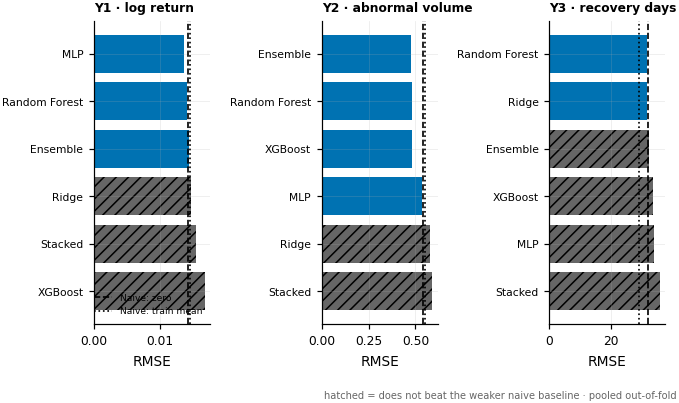

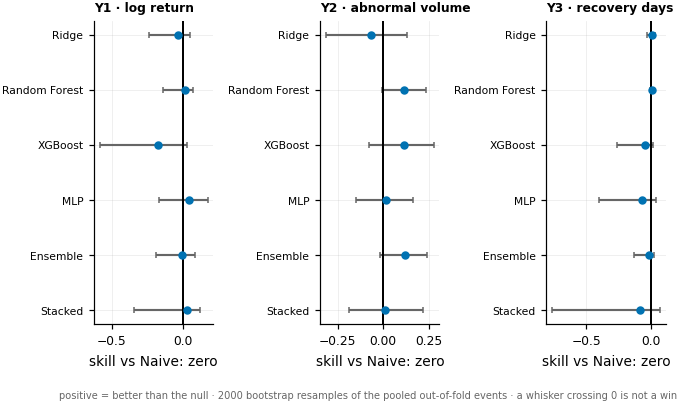

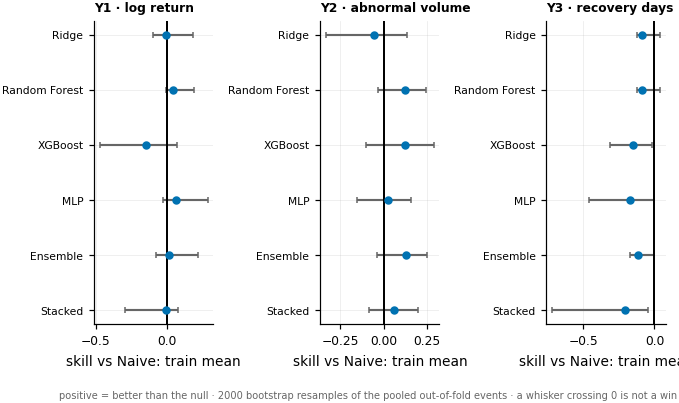

In [5]:
fig = fx.plot_model_vs_baseline(results, TARGET_COLS)
fx.save_figure(fig, "fig_17_model_vs_naive_baseline")

fig = fx.plot_skill_forest(results, TARGET_COLS, reference="naive_zero")
fx.save_figure(fig, "fig_18_skill_forest_vs_naive_zero")

fig = fx.plot_skill_forest(results, TARGET_COLS, reference="naive_train_mean")
fx.save_figure(fig, "fig_18b_skill_forest_vs_train_mean")


saved -> docs\figures\fig_19_pred_vs_actual_y1.png (157 KB)


saved -> docs\figures\fig_19_pred_vs_actual_y2.png (167 KB)


saved -> docs\figures\fig_19_pred_vs_actual_y3.png (133 KB)


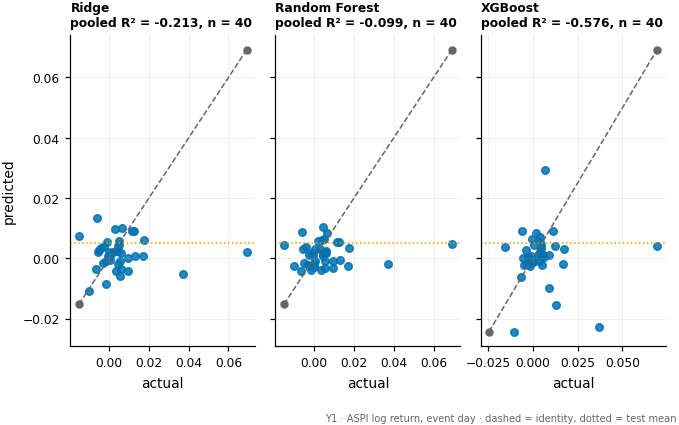

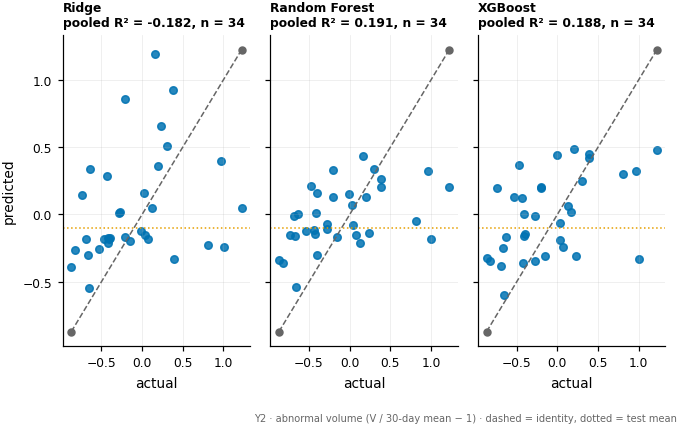

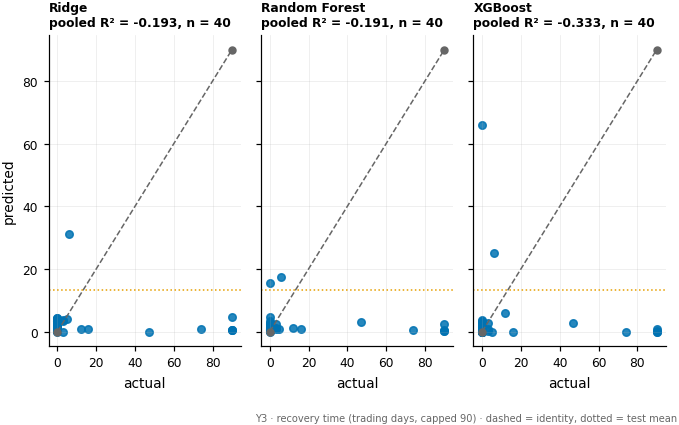

In [6]:
for t in TARGET_COLS:
    fig = fx.plot_pred_vs_actual(results, ["ridge", "random_forest", "xgboost"], t)
    fx.save_figure(fig, f"fig_19_pred_vs_actual_{t.split('_')[0].lower()}")


### Recommended Model Per Target, and Train-Fit R-squared (Supplementary)

**Random Forest is recommended for Y1 and Y2**, where it achieves the lowest RMSE and the least-negative pooled R-squared of the six candidates in the table above.

**On Y3 it is not.** Ridge on the log1p-transformed target beats it on both metrics (RMSE 24.34 vs 29.33; pooled R-squared +0.038 vs -0.146) and is the only model-target pair in this study with a positive held-out R-squared. **Thesis H1 is therefore supported for Y1 and Y2 and rejected for Y3**: at this sample size, recovery duration carries little non-linear structure for the tree ensembles to exploit, and the gain came from a principled response transform rather than from model capacity. Reporting that split result is more informative than reporting a uniform win.

All six candidates stay in the table: Ridge is H1's designated comparator (thesis Section 3.8.1), and the ensemble and stacked rows are variance-reduction checks. They are kept as evidence, not as a menu that was searched for a winner.

The cell below reports **train-set fit R-squared**: RF refit on all real rows and scored on those same rows. It measures memorization, not prediction, and is never a substitute for the held-out figure. It is reported because the *gap* is itself the finding -- on Y3 the distance between in-sample 0.883 and held-out -0.146 quantifies how far a Random Forest at N=64 is fitting noise rather than signal.


saved -> docs\figures\fig_24_overfitting_gap.png (162 KB)
random_forest | Y1_aspi_log_return     train-fit R2=+0.8453   held-out R2=-0.0987   gap=0.9440
random_forest | Y2_abnormal_volume     train-fit R2=+0.8458   held-out R2=+0.1912   gap=0.6546
random_forest | Y3_recovery_days       train-fit R2=+0.4944   held-out R2=-0.1912   gap=0.6857


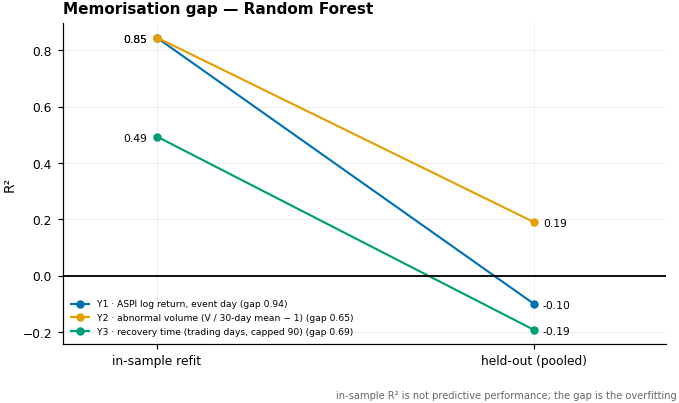

In [7]:
fig = fx.plot_overfitting_gap(train_fit_r2, results, TARGET_COLS, model="random_forest")
fx.save_figure(fig, "fig_24_overfitting_gap")

for t in TARGET_COLS:
    held = results["random_forest"][t]["pooled_r2"]
    print(f"random_forest | {t:<22s} train-fit R2={train_fit_r2[t]:+.4f}   "
          f"held-out R2={held:+.4f}   gap={train_fit_r2[t] - held:.4f}")


**RMSE is prioritized over MAE/R² as the primary metric** (thesis §3.8.1): it squares errors, disproportionately penalizing the large misses that matter most in disaster finance — under-predicting a 15% crash as a 2% dip is a materially worse failure than the squared-error metric alone even conveys, but RMSE weights it more than MAE does either way.

**Why `r2_per_fold_mean` is so negative, and why `r2_pooled` is shown alongside it as the fix, not just an explanation:** `TEST_WINDOW = 10` events per walk-forward fold (§8) means each per-fold R² is a ratio against that fold's own tiny 10-point mean — numerically unstable; a single unusual event in a 10-point test fold can swing it arbitrarily, and Y3 (recovery days, floor-heavy distribution) makes this worse still. Averaging several of these unstable per-fold ratios (`r2_per_fold_mean`) doesn't fix that instability, it just averages noise.

**`r2_pooled`** concatenates every fold's out-of-fold predictions and true values into one array first, then computes R² **once** over all of them together (§9's `run_walk_forward`) — the standard way to report R² for walk-forward/rolling-origin cross-validation. SS_tot is computed over the **30 pooled out-of-fold test points** (20 for the stacked model, which forfeits fold 0), not over the 64-event dataset: the `n` column in the table above makes this explicit. Read `r2_pooled`, not `r2_per_fold_mean`, as this notebook's R² number.

**Why the R² column looks so much worse than the RMSE column.** R² = 1 - SSE/SST, and SST here is computed against the *pooled test* mean — but every model can only ever centre on its *training-fold* mean. The chronological split compounds this: the two largest shocks in the dataset (2004-12-26 and 2005-11-21) fall permanently inside fold 0's **training** window, so the held-out folds contain the calmer events and carry only a fraction of the full-sample standard deviation — compare the `sigma_y_test` column against the full-sample σ in §6. A negative pooled R² here means "worse than an oracle that already knows the test set's mean", which is **not** the same as "worse than a usable baseline". The `beats_null_rmse` column is the answer to that second, more meaningful question.

**Y3 was redefined in this revision and its numbers are not comparable to earlier runs.** `build_targets()` previously returned a calendar-day difference while searching a window of 91 trading rows, so the 90-day cap actually bit at roughly 62 trading days (see §6). It now returns trading days, as thesis §3.2.2 specifies. Every Y3 figure below is therefore on a new scale: read it as a fresh baseline, not as an improvement over the previously reported Y3 results. Y1 and Y2 are unaffected and remain directly comparable.


### Prediction Intervals (Rolling Conformal, Approximate Coverage)

Point predictions alone hide how uncertain the model is. Conformal intervals address that
without new data, new fits, or a distributional assumption: absolute residuals from PRIOR
folds give an empirical error quantile, and fold i's interval is `prediction +/- q`. Because
the quantile comes only from earlier folds, coverage measured on later folds is genuine
out-of-sample coverage rather than a circular re-fit of the same rows.

**This is a rolling/online conformal procedure, not split-conformal, and the distinction
matters.** Textbook split-conformal draws its calibration residuals from a held-out split of
the SAME fitted model, which is what buys the finite-sample coverage guarantee. Here the
residuals come from *different model instances* trained on *different windows* of a
*non-stationary* series, so the exchangeability assumption the guarantee rests on does not
hold. An earlier version of this section claimed a distribution-free guarantee; that claim
was too strong and is withdrawn. What remains is an empirical, and still useful, calibration
check.

Two corrections to how the numbers are computed and read:

- **Finite-sample quantile.** Conformal prediction requires the
  `ceil((n+1)(1-alpha))/n` empirical quantile, not the plain `(1-alpha)` one. At n=10
  calibration points the plain quantile under-covers by construction.
- **A marginal baseline.** A wide interval buys coverage cheaply, so coverage alone proves
  nothing about the model. Each model interval is therefore printed beside a *marginal*
  interval built by the identical procedure around a constant (the prior-fold median). If
  the model's interval is not materially narrower at comparable coverage, the model is
  contributing nothing to the uncertainty estimate.

Coverage is reported with a Wilson confidence interval: at 20 test points each observation
is worth 5 percentage points, so an observed 80.0% is the nearest achievable value to target,
not evidence of precision. Widths are reported as half-widths (`+/- x`), the form the
interval is actually read in.


In [8]:
ALPHA = 0.20  # target 80% coverage


def wilson_ci(k, n, z=1.96):
    """Wilson score interval for a proportion. Preferred to the normal approximation
    at these sample sizes, where the latter can run outside [0, 1]."""
    if n == 0:
        return float("nan"), float("nan")
    p = k / n
    denom = 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)


def conformal_q(resid, alpha=ALPHA):
    """Finite-sample conformal quantile: the ceil((n+1)(1-alpha))-th smallest absolute
    residual, not the plain (1-alpha) empirical quantile. Where the requested level
    cannot be certified at this n, falls back to the largest residual observed."""
    resid = np.sort(np.asarray(resid, dtype=float))
    n = len(resid)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    return float(resid[min(k, n) - 1])


print(f"Rolling conformal intervals, target coverage {1 - ALPHA:.0%}. Calibration residuals")
print("come from PRIOR folds only; fold 0 has none and is skipped. 'marginal' applies the")
print("identical procedure to a constant predictor (the prior-fold median) -- the model's")
print("interval has to be NARROWER than that at comparable coverage to be worth anything.\n")

# Random Forest only. The stacked model forfeits fold 0 to its meta-learner and so has
# just 10 calibration residuals here; an 80% quantile of 10 points is not an estimate,
# and reporting it invited exactly the over-reading this section is correcting.
coverage_rows = []  # collected for the coverage figure below
for t in TARGET_COLS:
    folds_yt = results["random_forest"][t]["y_true"]
    folds_yp = results["random_forest"][t]["y_pred"]
    cov = cov_m = total = 0
    widths, widths_m = [], []
    for i in range(1, len(folds_yt)):
        prior_yt = np.concatenate(folds_yt[:i])
        prior_yp = np.concatenate(folds_yp[:i])
        yt_i = folds_yt[i]

        q = conformal_q(np.abs(prior_yt - prior_yp))
        lo, hi = clip_to_bounds(t, folds_yp[i] - q), clip_to_bounds(t, folds_yp[i] + q)
        cov += int(np.sum((yt_i >= lo) & (yt_i <= hi)))
        widths.append(float(np.mean(hi - lo)) / 2.0)

        # Marginal: same machinery, constant predictor.
        med = float(np.median(prior_yt))
        q_m = conformal_q(np.abs(prior_yt - med))
        lo_m = clip_to_bounds(t, np.full(len(yt_i), med - q_m))
        hi_m = clip_to_bounds(t, np.full(len(yt_i), med + q_m))
        cov_m += int(np.sum((yt_i >= lo_m) & (yt_i <= hi_m)))
        widths_m.append(float(np.mean(hi_m - lo_m)) / 2.0)

        total += len(yt_i)

    lo_ci, hi_ci = wilson_ci(cov, total)
    lo_ci_m, hi_ci_m = wilson_ci(cov_m, total)
    narrower = "NARROWER than marginal" if np.mean(widths) < np.mean(widths_m) else "NOT narrower than marginal"
    print(f"{t}")
    print(f"  random_forest : coverage={cov / total:.1%} ({cov}/{total})  "
          f"Wilson 95% CI [{lo_ci:.0%}, {hi_ci:.0%}]  half-width=+/-{np.mean(widths):.4f}")
    print(f"  marginal      : coverage={cov_m / total:.1%} ({cov_m}/{total})  "
          f"Wilson 95% CI [{lo_ci_m:.0%}, {hi_ci_m:.0%}]  half-width=+/-{np.mean(widths_m):.4f}")
    print(f"  -> model interval is {narrower}\n")
    coverage_rows.append({"target": t, "kind": "model", "coverage": cov / total,
                          "covered": cov, "n": total, "half_width": float(np.mean(widths)),
                          "nominal": 1 - ALPHA})
    coverage_rows.append({"target": t, "kind": "marginal", "coverage": cov_m / total,
                          "covered": cov_m, "n": total, "half_width": float(np.mean(widths_m)),
                          "nominal": 1 - ALPHA})


Rolling conformal intervals, target coverage 80%. Calibration residuals
come from PRIOR folds only; fold 0 has none and is skipped. 'marginal' applies the
identical procedure to a constant predictor (the prior-fold median) -- the model's
interval has to be NARROWER than that at comparable coverage to be worth anything.

Y1_aspi_log_return
  random_forest : coverage=76.7% (23/30)  Wilson 95% CI [59%, 88%]  half-width=+/-0.0094
  marginal      : coverage=66.7% (20/30)  Wilson 95% CI [49%, 81%]  half-width=+/-0.0084
  -> model interval is NOT narrower than marginal

Y2_abnormal_volume
  random_forest : coverage=83.3% (20/24)  Wilson 95% CI [64%, 93%]  half-width=+/-0.6288
  marginal      : coverage=50.0% (12/24)  Wilson 95% CI [31%, 69%]  half-width=+/-0.4820
  -> model interval is NOT narrower than marginal

Y3_recovery_days
  random_forest : coverage=80.0% (24/30)  Wilson 95% CI [63%, 90%]  half-width=+/-7.9018
  marginal      : coverage=73.3% (22/30)  Wilson 95% CI [56%, 86%]  half-wid

saved -> docs\figures\fig_11_conformal_coverage.png (111 KB)


cached conformal_coverage.parquet  (6 rows x 7 cols)


WindowsPath('F:/CSE-disaster-impact-predictor/disaster_finance_predictor/artifacts/conformal_coverage.parquet')

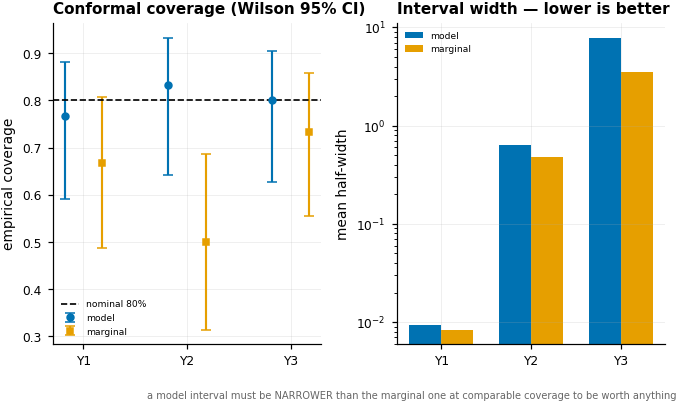

In [9]:
coverage = pd.DataFrame(coverage_rows)
fig = fx.plot_conformal_coverage(coverage)
fx.save_figure(fig, "fig_11_conformal_coverage")
save_frame(coverage, "conformal_coverage", "Model vs marginal interval coverage and width.")


### Directional Accuracy, Against Its Own Baseline (Y1, Secondary Metric)

RMSE/MAE/R-squared are the thesis's mandated metrics (Section 3.8.1) and remain primary. As a secondary signal: does the model get the **direction** of the ASPI move right (crash vs. no-crash)?

**An accuracy figure is meaningless without the baseline it must beat.** The classes here are imbalanced (10 crashes in 30 pooled test events), so a model that predicts "no crash" every single time already scores 66.7%. Every accuracy below is therefore printed next to that majority-class baseline, and the comparison is stated explicitly rather than left for the reader to compute. AUC is reported alongside because it is baseline-free, with the Hanley-McNeil confidence interval, since at n=30 with 10 positives an AUC point estimate on its own says very little.


In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

REPORTED_MODELS = [m for m in results if not m.startswith("naive_")]


def hanley_mcneil_ci(auc, n_pos, n_neg, z=1.96):
    """Standard error of an AUC estimate (Hanley & McNeil, 1982). At n=30 with 10
    positives this interval is wide, which is the point of reporting it."""
    q1 = auc / (2.0 - auc)
    q2 = 2.0 * auc ** 2 / (1.0 + auc)
    se = np.sqrt((auc * (1 - auc) + (n_pos - 1) * (q1 - auc ** 2)
                  + (n_neg - 1) * (q2 - auc ** 2)) / (n_pos * n_neg))
    return max(0.0, auc - z * se), min(1.0, auc + z * se)


print("Directional accuracy on Y1 (sign match, pooled across folds), each against the")
print("majority-class baseline for ITS OWN test set -- an accuracy below its baseline means")
print("the model is beaten by the constant rule 'predict no crash every time'.\n")
for name in REPORTED_MODELS:
    yt_all = np.concatenate(results[name][TARGET_COLS[0]]["y_true"])
    yp_all = np.concatenate(results[name][TARGET_COLS[0]]["y_pred"])
    acc = float(np.mean(np.sign(yt_all) == np.sign(yp_all)))
    n_crash = int((yt_all < 0).sum())
    baseline = max(n_crash, len(yt_all) - n_crash) / len(yt_all)  # always predict the larger class
    verdict = "BEATS baseline" if acc > baseline else ("ties baseline" if acc == baseline else "BELOW baseline")
    print(f"{name:>16s}: {acc:.1%}  vs majority-class baseline {baseline:.1%}  "
          f"-> {verdict}  (n={len(yt_all)}, {n_crash} crashes)")

print()
print("Same predictions reframed as a binary crash/no-crash classifier (Y1 < 0 = 'crash').")
print("Precision/recall/F1 only apply once the continuous target is thresholded into a class")
print("label like this; there is no such thing as precision/recall on a raw regression target.")
print("Note the positive class is the MINORITY class, so a high-recall/low-precision model is")
print("simply one that predicts 'crash' often.\n")
for name in REPORTED_MODELS:
    yt_all = np.concatenate(results[name][TARGET_COLS[0]]["y_true"])
    yp_all = np.concatenate(results[name][TARGET_COLS[0]]["y_pred"])
    yt_cls = (yt_all < 0).astype(int)
    yp_cls = (yp_all < 0).astype(int)
    p = precision_score(yt_cls, yp_cls, zero_division=0)
    r = recall_score(yt_cls, yp_cls, zero_division=0)
    f1 = f1_score(yt_cls, yp_cls, zero_division=0)
    prevalence = yt_cls.mean()  # precision of a coin-flip 'always guess crash' classifier
    print(f"{name:>16s}: precision={p:.3f} (prevalence={prevalence:.3f})  recall={r:.3f}  F1={f1:.3f}  "
          f"(n_crashes={int(yt_cls.sum())}/{len(yt_cls)})")

print()
print("AUC-ROC on the same reframing (score = -predicted Y1, so a bigger predicted drop scores")
print("more crash-like). AUC needs no baseline -- 0.5 IS chance -- but at this n the confidence")
print("interval is wide enough that none of these are distinguishable from chance.\n")
for name in REPORTED_MODELS:
    yt_all = np.concatenate(results[name][TARGET_COLS[0]]["y_true"])
    yp_all = np.concatenate(results[name][TARGET_COLS[0]]["y_pred"])
    yt_cls = (yt_all < 0).astype(int)
    n_pos, n_neg = int(yt_cls.sum()), int(len(yt_cls) - yt_cls.sum())
    if n_pos == 0 or n_neg == 0:
        continue
    auc = float(roc_auc_score(yt_cls, -yp_all))
    lo, hi = hanley_mcneil_ci(auc, n_pos, n_neg)
    excludes = "excludes 0.5" if lo > 0.5 else "includes 0.5 -- not distinguishable from chance"
    print(f"{name:>16s}: AUC={auc:.3f}  95% CI [{lo:.3f}, {hi:.3f}]  -> {excludes}")


Directional accuracy on Y1 (sign match, pooled across folds), each against the
majority-class baseline for ITS OWN test set -- an accuracy below its baseline means
the model is beaten by the constant rule 'predict no crash every time'.

           ridge: 60.0%  vs majority-class baseline 67.5%  -> BELOW baseline  (n=40, 13 crashes)
   random_forest: 55.0%  vs majority-class baseline 67.5%  -> BELOW baseline  (n=40, 13 crashes)
         xgboost: 60.0%  vs majority-class baseline 67.5%  -> BELOW baseline  (n=40, 13 crashes)
             mlp: 67.5%  vs majority-class baseline 67.5%  -> ties baseline  (n=40, 13 crashes)
        ensemble: 57.5%  vs majority-class baseline 67.5%  -> BELOW baseline  (n=40, 13 crashes)
         stacked: 70.0%  vs majority-class baseline 66.7%  -> BEATS baseline  (n=30, 10 crashes)

Same predictions reframed as a binary crash/no-crash classifier (Y1 < 0 = 'crash').
Precision/recall/F1 only apply once the continuous target is thresholded into a class
label like 

saved -> docs\figures\fig_14_roc_with_ci.png (193 KB)

Exported figures:
                              filename  kb
       fig_02_target_distributions.png 145
    fig_03_target_dependence_y1_y3.png 123
fig_04_feature_correlation_heatmap.png 550
           fig_06_collinearity_vif.png 292
         fig_09_walk_forward_folds.png 155
         fig_11_conformal_coverage.png 111
                fig_14_roc_with_ci.png 193
    fig_17_model_vs_naive_baseline.png 122
 fig_18_skill_forest_vs_naive_zero.png  84
fig_18b_skill_forest_vs_train_mean.png  84
          fig_19_pred_vs_actual_y1.png 157
          fig_19_pred_vs_actual_y2.png 167
          fig_19_pred_vs_actual_y3.png 133
            fig_24_overfitting_gap.png 162
  fig_31_sector_response_and_skill.png 221


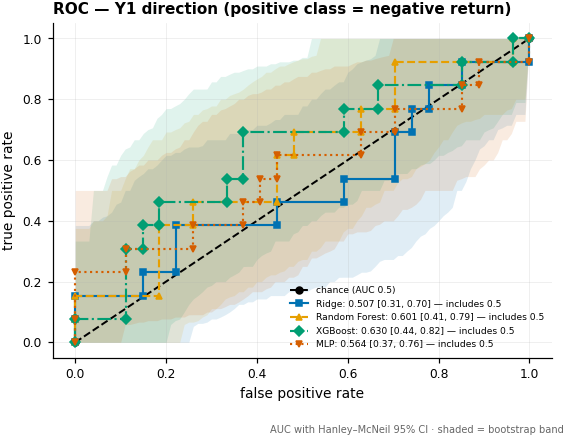

In [11]:
fig = fx.plot_roc_with_ci(results, ["ridge", "random_forest", "xgboost", "mlp"])
fx.save_figure(fig, "fig_14_roc_with_ci")

print("\nExported figures:")
print(fx.figure_manifest().to_string(index=False))
